# Fourier Analysis and Guided Initialization

Refactored notebook to study the periodic VQE landscape without noise. The goal is to show when a low-order Fourier approximation helps choose a better initial point for the optimizer.


## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fourier import (
    analyze_fourier_line,
    build_fourier_problem,
    estimate_first_harmonic_guided_point,
    make_coordinate_direction,
    run_budget_comparison,
    run_vqe_reference_point,
    scan_harmonic_error,
    scan_spectral_profile,
    spectral_metrics,
)
from src.vqe.ansatz import build_ansatz
from src.vqe.molecular_system import default_statevector_systems
from src.visualization.fourier_plots import (
    plot_budget_comparison,
    plot_fourier_reconstruction,
    plot_harmonic_error,
    plot_harmonic_profile,
    plot_spectral_metrics,
    save_figure,
)

pd.set_option("display.max_columns", None)

output_dir = "outputs/figures/fourier"
seed = 137


## Systems and Configuration

We start with `H2`, `LiH`, and `BeH2` in `sto-3g`, using a small distance grid. This keeps the notebook practical for generating slide figures.


In [2]:
systems = [
    system
    for system in default_statevector_systems()
    if system.name in {"H2", "LiH", "BeH2"}
]

ansatz_name = "real_amplitudes"
reps = 2
mapper = "parity"
z2symmetry_reduction = True
optimizer_name = "cobyla"
reference_max_iter = 250
theta_samples = 64

[(system.name, system.basis, system.distances, system.active_space) for system in systems]


[('H2', 'sto-3g', (0.5, 0.735, 1.0), None),
 ('LiH', 'sto-3g', (1.2, 1.5949, 2.2), (2, 3)),
 ('BeH2', 'sto-3g', (0.8, 1.4, 2.0), (4, 4))]

## Demonstration: Fourier Lines for H2, LiH, and BeH2

For each molecule, we choose a point near the VQE optimum, vary one parameter at a time, and reconstruct `E(theta)` with a few harmonics.


In [3]:
fourier_lines = {}
fourier_contexts = {}

for demo_system in systems:
    demo_distance = demo_system.distances[len(demo_system.distances) // 2]

    problem, qubit_op, constant_energy = build_fourier_problem(
        demo_system,
        demo_distance,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
    )
    ansatz = build_ansatz(
        name=ansatz_name,
        num_qubits=qubit_op.num_qubits,
        reps=reps,
        num_particles=problem.num_particles,
        num_spatial_orbitals=problem.num_spatial_orbitals,
    )

    vqe_reference = run_vqe_reference_point(
        qubit_op=qubit_op,
        ansatz=ansatz,
        constant_energy=constant_energy,
        optimizer_name=optimizer_name,
        max_iter=reference_max_iter,
        seed=seed,
    )
    if not vqe_reference.get("success", False):
        print(f"Falha no VQE de referência para {demo_system.name}: {vqe_reference.get('error')}")
        continue

    center = np.asarray(vqe_reference["optimal_params"], dtype=float)
    direction = make_coordinate_direction(ansatz.num_parameters, parameter_index=0)
    line = analyze_fourier_line(
        ansatz=ansatz,
        qubit_op=qubit_op,
        constant_energy=constant_energy,
        center=center,
        direction=direction,
        theta_samples=theta_samples,
    )

    fourier_lines[demo_system.name] = line
    fourier_contexts[demo_system.name] = {
        "system": demo_system,
        "distance": demo_distance,
        "problem": problem,
        "qubit_op": qubit_op,
        "constant_energy": constant_energy,
        "ansatz": ansatz,
        "center": center,
        "direction": direction,
    }

pd.DataFrame([
    {
        "molecule": molecule,
        "basis": ctx["system"].basis,
        "distance": ctx["distance"],
        **spectral_metrics(line.coefficients),
    }
    for molecule, line in fourier_lines.items()
    for ctx in [fourier_contexts[molecule]]
])


,molecule,basis,distance,r1,h_norm
0,H2,sto-3g,0.7350,1.0,4.917685e-30
1,LiH,sto-3g,1.5949,1.0,2.949801e-29
2,BeH2,sto-3g,1.4000,1.0,4.936115e-30


outputs/figures/fourier/fourier_reconstruction_H2_LiH_BeH2.png


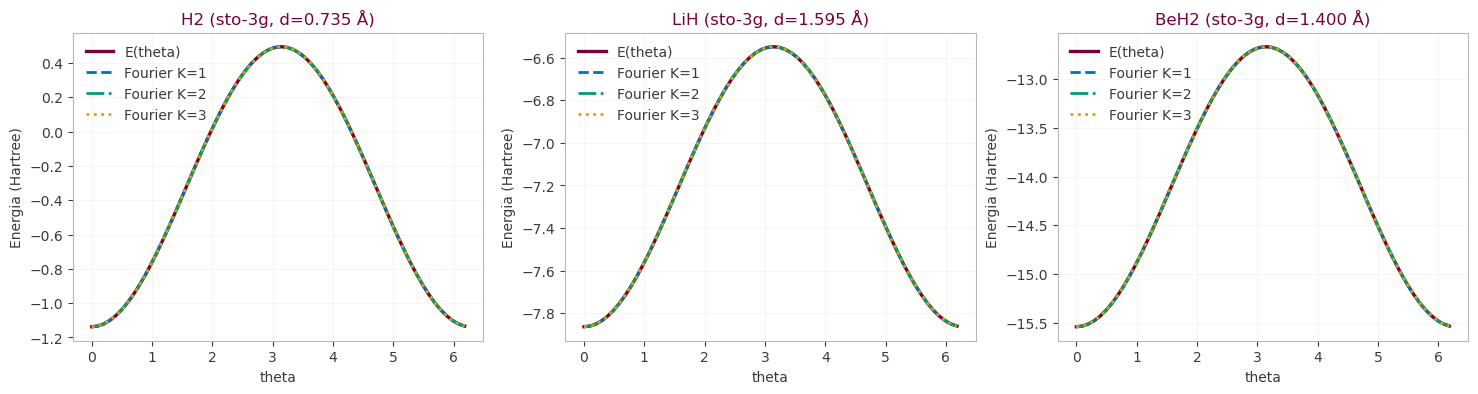

In [14]:
fig, axes = plt.subplots(1, len(fourier_lines), figsize=(6 * len(fourier_lines), 4), squeeze=False)

for ax, (molecule, line) in zip(axes.ravel(), fourier_lines.items()):
    plot_fourier_reconstruction(line, harmonic_orders=(1, 2, 3), ax=ax)
    ctx = fourier_contexts[molecule]
    ax.set_title(f"{molecule} ({ctx['basis'] if 'basis' in ctx else ctx['system'].basis}, d={ctx['distance']:.3f} Å)")

path = save_figure(fig, output_dir, "fourier_reconstruction_H2_LiH_BeH2.png")
print(path)
plt.show()


## Guided Initial Point

Using three evaluations at `theta = 0, pi/2, -pi/2`, we estimate the first harmonic and compute the analytical minimum of that approximation.


In [5]:
demo_name = "H2"
ctx = fourier_contexts[demo_name]

guided_point, guide_cost, guide_info = estimate_first_harmonic_guided_point(
    ansatz=ctx["ansatz"],
    qubit_op=ctx["qubit_op"],
    constant_energy=ctx["constant_energy"],
    center=ctx["center"],
    direction=ctx["direction"],
)

pd.DataFrame([{
    "molecule": demo_name,
    "basis": ctx["system"].basis,
    "distance": ctx["distance"],
    "guide_cost": guide_cost,
    **guide_info,
}])


,molecule,basis,distance,guide_cost,a1,b1,theta_star,first_harmonic_amplitude
0,H2,sto-3g,0.735,3,-0.816182,-0.000005,0.000006,0.816182


## Local vs Global Spectral Profile

`R1` measures how much spectral weight is concentrated in the first harmonic. `H_norm` measures how spread out the energy is across harmonics.


In [6]:
RUN_SPECTRAL_SCAN = True

if RUN_SPECTRAL_SCAN:
    spectral_df, profile_df = scan_spectral_profile(
        systems=systems,
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        max_iter=reference_max_iter,
        theta_samples=theta_samples,
        seed=seed,
        global_samples=3,
        max_harmonics=8,
    )

    display(spectral_df.head())
    display(profile_df.head())


,molecule,basis,distance,regime,r1,h_norm
0,H2,sto-3g,0.500,local,1.000000,3.561439e-30
1,H2,sto-3g,0.500,global,0.057469,2.537743e-01
2,H2,sto-3g,0.500,global,0.529996,4.028654e-01
3,H2,sto-3g,0.500,global,0.916885,1.239102e-01
4,H2,sto-3g,0.735,local,1.000000,4.917685e-30


,molecule,basis,distance,regime,k,normalized_amplitude
0,H2,sto-3g,0.5,local,1,1.000000e+00
1,H2,sto-3g,0.5,local,2,2.152111e-17
2,H2,sto-3g,0.5,local,3,9.642319e-17
3,H2,sto-3g,0.5,local,4,1.017305e-16
4,H2,sto-3g,0.5,local,5,1.911126e-16


outputs/figures/fourier/fourier_harmonic_profile.png


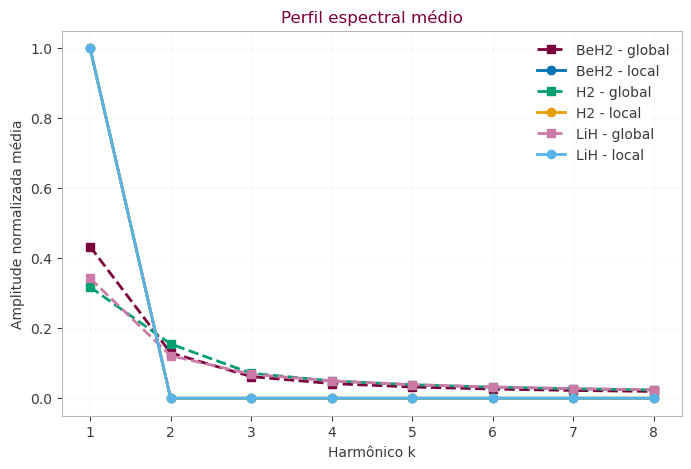

outputs/figures/fourier/fourier_spectral_metrics.png


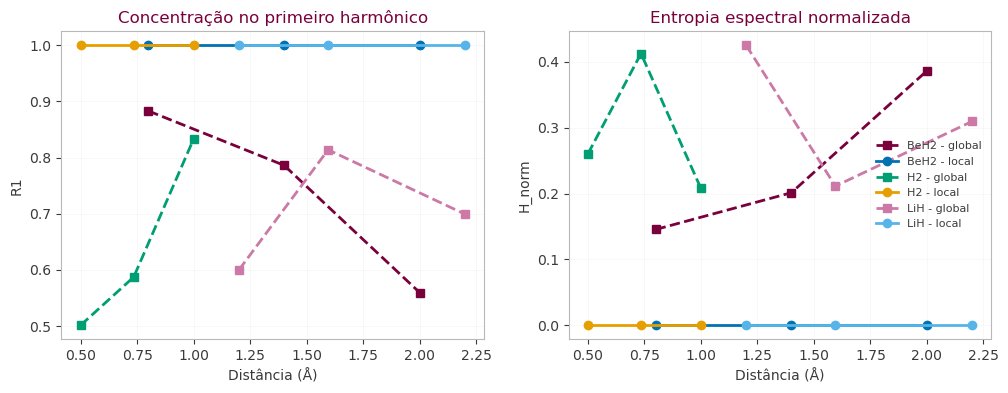

In [7]:
if RUN_SPECTRAL_SCAN:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_harmonic_profile(profile_df, ax=ax)
    path = save_figure(fig, output_dir, "fourier_harmonic_profile.png")
    print(path)
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_spectral_metrics(spectral_df, ax=ax)
    path = save_figure(fig, output_dir, "fourier_spectral_metrics.png")
    print(path)
    plt.show()


## Error vs Harmonic Order

This block shows whether `K=1` is already enough or whether additional harmonics are needed to reconstruct the curve and its minimum.


In [8]:
RUN_HARMONIC_ERROR = True

if RUN_HARMONIC_ERROR:
    harmonic_error_df = scan_harmonic_error(
        systems=systems,
        harmonic_grid=(1, 2, 3, 5),
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        max_iter=reference_max_iter,
        theta_samples=theta_samples,
        seed=seed,
    )

    harmonic_summary = (
        harmonic_error_df.groupby(["molecule", "K"], as_index=False)
        .agg(mean_rmse=("rmse", "mean"), mean_delta_min=("delta_min_energy", "mean"))
        .sort_values(["molecule", "K"])
    )
    display(harmonic_summary)


,molecule,K,mean_rmse,mean_delta_min
0,BeH2,1,1.588797e-15,0.0
1,BeH2,2,1.588797e-15,0.0
2,BeH2,3,1.588797e-15,0.0
3,BeH2,5,1.588797e-15,0.0
4,H2,1,3.875670e-16,0.0
5,H2,2,3.895719e-16,0.0
6,H2,3,3.887373e-16,0.0
7,H2,5,3.778270e-16,0.0
8,LiH,1,7.306583e-16,0.0
9,LiH,2,7.306583e-16,0.0


outputs/figures/fourier/fourier_error_vs_k.png


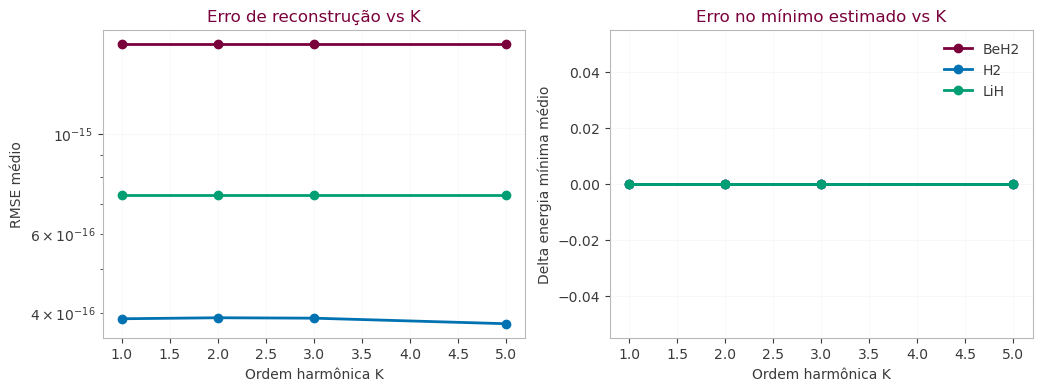

In [9]:
if RUN_HARMONIC_ERROR:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_harmonic_error(harmonic_error_df, ax=ax)
    path = save_figure(fig, output_dir, "fourier_error_vs_k.png")
    print(path)
    plt.show()


## Random Initialization vs Fourier-Guided

Main hypothesis: guided initialization improves the same random initial point, especially when the optimizer has a small iteration budget.


In [10]:
RUN_BUDGET_COMPARISON = True

if RUN_BUDGET_COMPARISON:
    budget_df = run_budget_comparison(
        systems=systems,
        iteration_grid=(25, 50, 100, 200),
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        seed=seed,
        repeats=3,
    )

    budget_summary = (
        budget_df.groupby(["max_iter", "molecule", "mode"], as_index=False)
        .agg(mean_total_cost=("total_cost", "mean"), mean_abs_error=("abs_error", "mean"))
        .sort_values(["molecule", "max_iter", "mode"])
    )
    display(budget_summary)


,max_iter,molecule,mode,mean_total_cost,mean_abs_error
0,25,BeH2,fourier_guided,28.000000,2.864091e-01
1,25,BeH2,random,25.000000,2.976232e-01
6,50,BeH2,fourier_guided,53.000000,2.467414e-01
7,50,BeH2,random,50.000000,1.674140e-01
12,100,BeH2,fourier_guided,103.000000,1.557388e-01
13,100,BeH2,random,100.000000,7.768957e-02
18,200,BeH2,fourier_guided,203.000000,3.961207e-02
19,200,BeH2,random,200.000000,9.958717e-02
2,25,H2,fourier_guided,28.000000,3.947460e-16
3,25,H2,random,25.000000,5.897399e-06


outputs/figures/fourier/fourier_budget_comparison.png


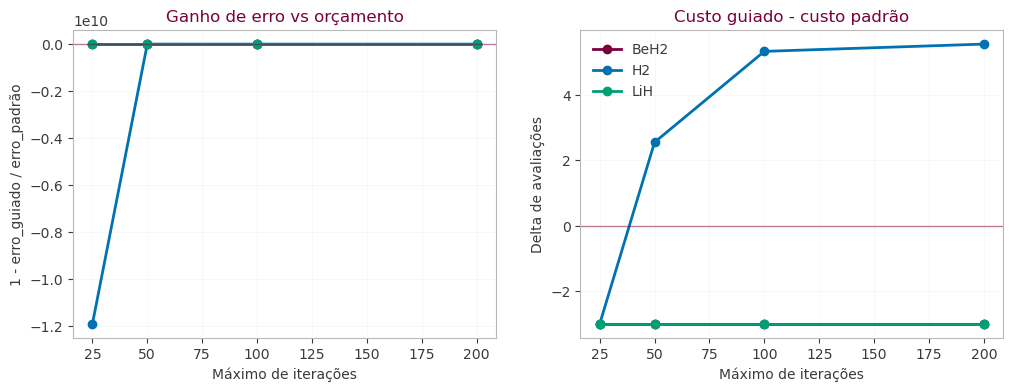

In [11]:
if RUN_BUDGET_COMPARISON:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_budget_comparison(budget_df, ax=ax)
    path = save_figure(fig, output_dir, "fourier_budget_comparison.png")
    print(path)
    plt.show()


## Data for Slides


In [12]:
for name in ["spectral_df", "profile_df", "harmonic_error_df", "budget_df"]:
    if name in globals():
        print(name, globals()[name].shape)

# Exemplo de tabela compacta para copiar para slide/texto.
if "budget_df" in globals():
    display(
        budget_df.groupby(["max_iter", "molecule", "mode"], as_index=False)
        .agg(
            mean_error=("abs_error", "mean"),
            median_error=("abs_error", "median"),
            mean_total_cost=("total_cost", "mean"),
        )
        .sort_values(["molecule", "max_iter", "mode"])
    )


spectral_df (36, 6)
profile_df (288, 6)
harmonic_error_df (36, 6)
budget_df (216, 16)


,max_iter,molecule,mode,mean_error,median_error,mean_total_cost
0,25,BeH2,fourier_guided,2.864091e-01,3.236805e-01,28.000000
1,25,BeH2,random,2.976232e-01,2.733488e-01,25.000000
6,50,BeH2,fourier_guided,2.467414e-01,1.579829e-01,53.000000
7,50,BeH2,random,1.674140e-01,1.219886e-01,50.000000
12,100,BeH2,fourier_guided,1.557388e-01,2.734631e-02,103.000000
13,100,BeH2,random,7.768957e-02,3.732592e-02,100.000000
18,200,BeH2,fourier_guided,3.961207e-02,5.309783e-03,203.000000
19,200,BeH2,random,9.958717e-02,7.415415e-03,200.000000
2,25,H2,fourier_guided,3.947460e-16,4.440892e-16,28.000000
3,25,H2,random,5.897399e-06,3.270778e-07,25.000000


### Initialization Relevance vs Budget
This cell summarizes the central idea: guided initialization tends to matter more when the optimizer has few iterations.
With more iterations, the difference between starting from a random point and from the Fourier-guided point should shrink.


,max_iter,molecule,mean_error_guided,mean_error_random,median_error_guided,median_error_random,mean_cost_guided,mean_cost_random,absolute_error_gain,relative_error_gain,cost_delta
0,25,BeH2,0.286409,0.297623,28.000000,25.000000,0.323680,2.733488e-01,0.011214,0.037679,5.033172e-02
3,50,BeH2,0.246741,0.167414,53.000000,50.000000,0.157983,1.219886e-01,-0.079327,-0.473840,3.599437e-02
6,100,BeH2,0.155739,0.077690,103.000000,100.000000,0.027346,3.732592e-02,-0.078049,-1.004630,-9.979610e-03
9,200,BeH2,0.039612,0.099587,203.000000,200.000000,0.005310,7.415420e-03,0.059975,0.602237,-2.105630e-03
1,25,H2,0.000000,0.000006,28.000000,25.000000,0.000000,3.300000e-07,0.000006,1.000000,-3.300000e-07
4,50,H2,0.000000,0.000000,32.222222,34.777778,0.000000,0.000000e+00,0.000000,0.999997,-0.000000e+00
7,100,H2,0.000000,0.000000,32.111111,37.444444,0.000000,0.000000e+00,0.000000,0.999999,-0.000000e+00
10,200,H2,0.000000,0.000000,32.000000,37.555556,0.000000,0.000000e+00,0.000000,0.999998,-0.000000e+00
2,25,LiH,0.096689,0.104765,28.000000,25.000000,0.079149,1.028454e-01,0.008077,0.077091,-2.369641e-02
5,50,LiH,0.022248,0.024171,53.000000,50.000000,0.014606,1.293831e-02,0.001923,0.079560,1.667960e-03


outputs/figures/fourier/fourier_initialization_relevance_vs_iterations.png


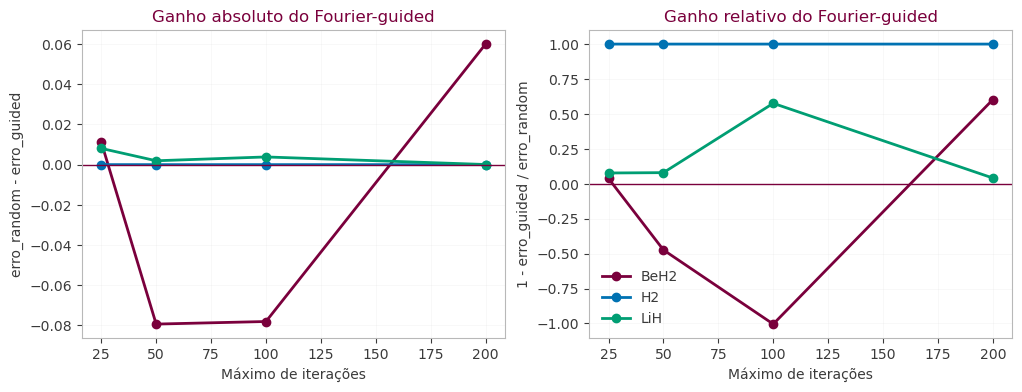

In [13]:
if "budget_df" not in globals():
    raise RuntimeError("Execute primeiro a seção 'Inicialização Aleatória vs Fourier-Guided'.")

iteration_effect = (
    budget_df.groupby(["max_iter", "molecule", "mode"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_total_cost=("total_cost", "mean"),
    )
)

iteration_wide = iteration_effect.pivot_table(
    index=["max_iter", "molecule"],
    columns="mode",
    values=["mean_abs_error", "median_abs_error", "mean_total_cost"],
    aggfunc="first",
).reset_index()
iteration_wide.columns = [
    "max_iter",
    "molecule",
    "mean_error_guided",
    "mean_error_random",
    "median_error_guided",
    "median_error_random",
    "mean_cost_guided",
    "mean_cost_random",
]

iteration_wide["absolute_error_gain"] = (
    iteration_wide["mean_error_random"] - iteration_wide["mean_error_guided"]
)
iteration_wide["relative_error_gain"] = 1.0 - (
    iteration_wide["mean_error_guided"] / (iteration_wide["mean_error_random"] + 1e-16)
)
iteration_wide["cost_delta"] = (
    iteration_wide["mean_cost_guided"] - iteration_wide["mean_cost_random"]
)

display(iteration_wide.sort_values(["molecule", "max_iter"]).round(8))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for molecule, group in iteration_wide.groupby("molecule"):
    group = group.sort_values("max_iter")
    ax[0].plot(
        group["max_iter"],
        group["absolute_error_gain"],
        marker="o",
        linewidth=2,
        label=molecule,
    )
    ax[1].plot(
        group["max_iter"],
        group["relative_error_gain"],
        marker="o",
        linewidth=2,
        label=molecule,
    )

ax[0].axhline(0.0, color="#7a003c", linewidth=1)
ax[0].set_title("Ganho absoluto do Fourier-guided")
ax[0].set_xlabel("Máximo de iterações")
ax[0].set_ylabel("erro_random - erro_guided")
ax[0].grid(alpha=0.25)

ax[1].axhline(0.0, color="#7a003c", linewidth=1)
ax[1].set_title("Ganho relativo do Fourier-guided")
ax[1].set_xlabel("Máximo de iterações")
ax[1].set_ylabel("1 - erro_guided / erro_random")
ax[1].grid(alpha=0.25)
ax[1].legend()

path = save_figure(fig, output_dir, "fourier_initialization_relevance_vs_iterations.png")
print(path)
plt.show()
